### USA House Price Prediction

![](https://i.imgur.com/9bXjPA5.gif)

I deployed the model.you can visit it [here](https://dibkb-houseprice.herokuapp.com/)

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
pd.set_option('display.max_colwidth', None)
%matplotlib inline
plt.style.use("seaborn")
#hide warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
#import the dataset
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
df = pd.read_csv('/kaggle/input/usa-housing/USA_Housing.csv')

/kaggle/input/usa-housing/USA_Housing.csv


In [3]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 37010-5101"
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA 48958"
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482-3489"
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01707-9165"
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [5]:
df['Address'].tail()

4995                           USNS Williams\nFPO AP 30153-7653
4996                      PSC 9258, Box 8489\nAPO AA 42991-3352
4997     4215 Tracy Garden Suite 076\nJoshualand, VA 01707-9165
4998                                  USS Wallace\nFPO AE 73316
4999    37778 George Ridges Apt. 509\nEast Holly, NV 29290-3595
Name: Address, dtype: object

#### Feature Engineeing

In [6]:
def extract_address(x):
    try:
        address = x.split('\n')[1].split(',')[1].split()[0]
    except IndexError:
        address = x.split('\n')[1].split(" ")[1]
    return address

In [7]:
df['Address'] = df['Address'].apply(extract_address)
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,NE
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,CA
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,WI
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,AP
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,AE
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,AP
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,AA
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,VA
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,AE


In [8]:
df['Address'].nunique()

62

### Univariate Data Analysis

#### Descriptive Statistics

In [9]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


#### Check for missing values

<AxesSubplot:>

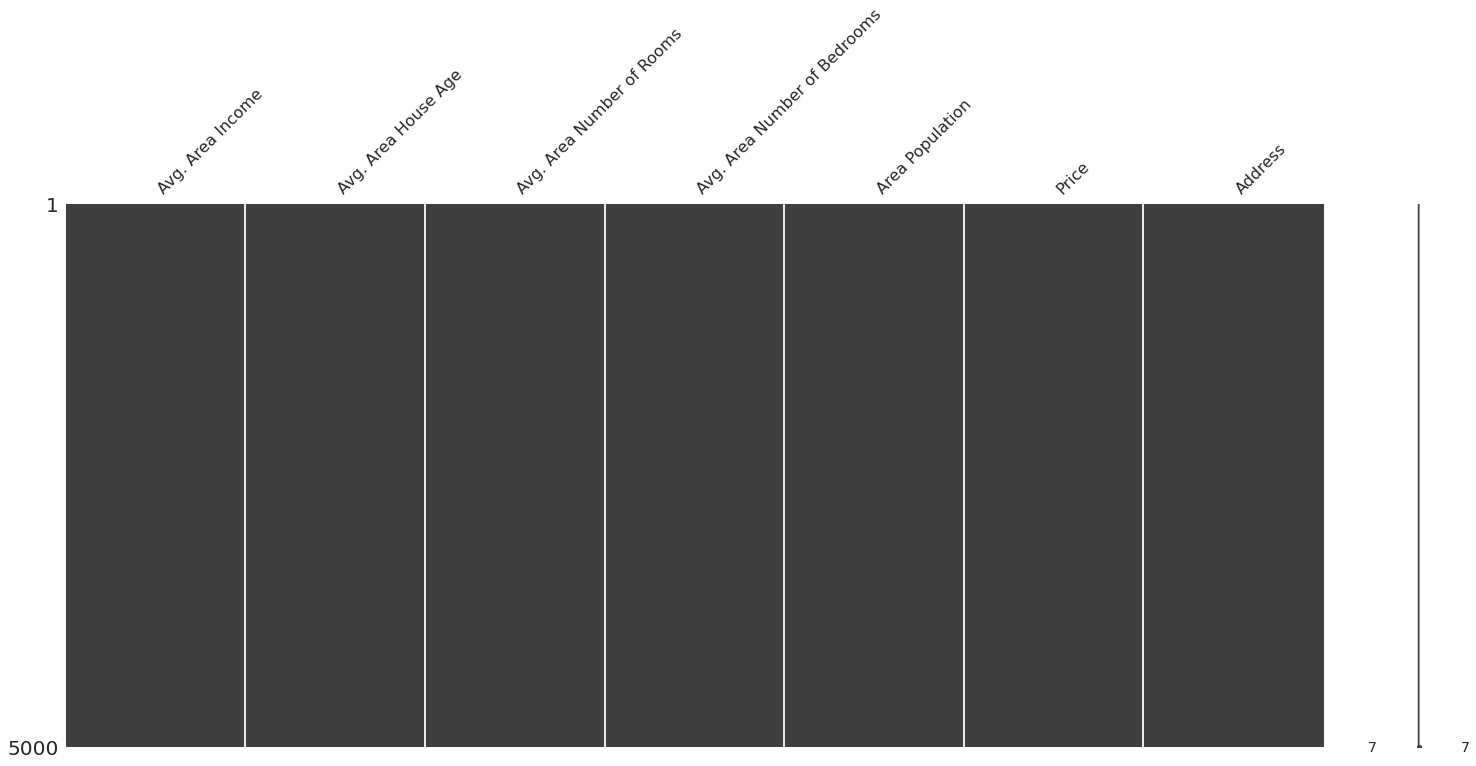

In [10]:
import missingno as msno
msno.matrix(df)

#### Distribution of numerical columns

In [11]:
import random
def random_color():
    r = lambda: random.randint(0,255)
    return '#%02X%02X%02X' % (r(),r(),r())

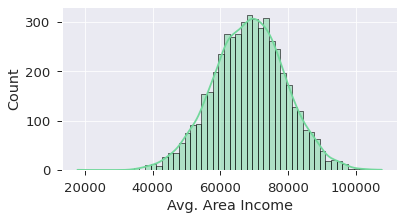

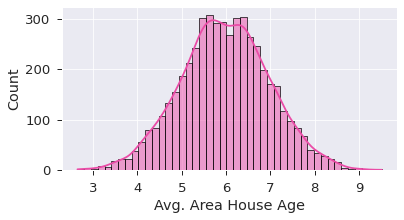

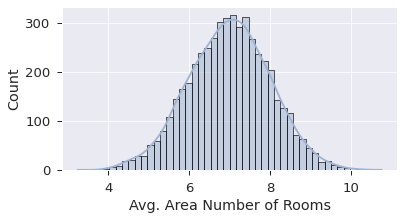

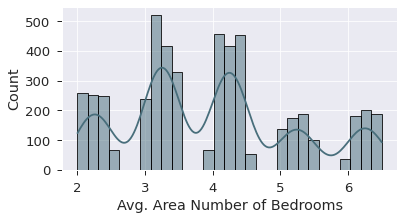

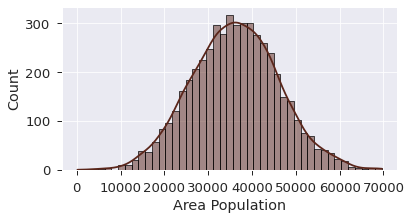

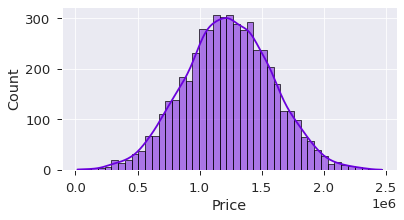

In [12]:
sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 1.8})
for i in df.columns[:-1]:
    fig,ax = plt.subplots(figsize = (6,3))
    sns.histplot(df[i],kde = True,color = random_color())

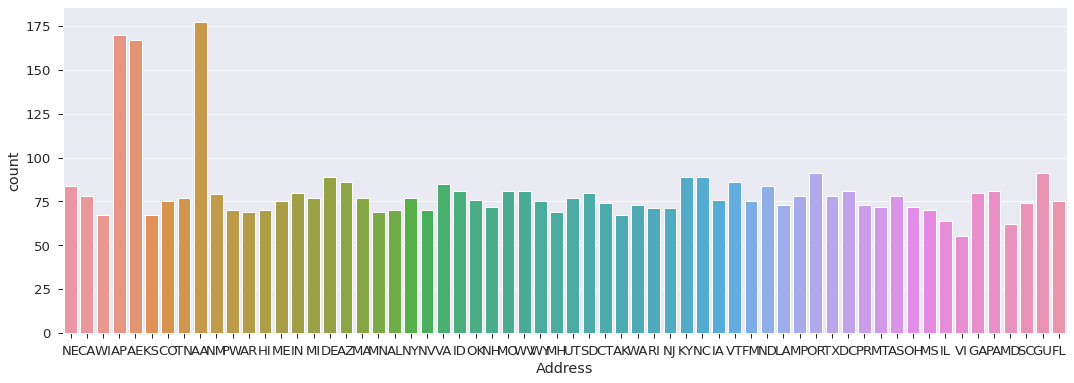

In [13]:
#Address count plot
fig,ax = plt.subplots(figsize = (18,6))
sns.set_theme(style="darkgrid")
ax = sns.countplot(x="Address", data=df)

#### Skewness


In [14]:
df.skew()

Avg. Area Income               -0.033720
Avg. Area House Age            -0.007214
Avg. Area Number of Rooms      -0.040996
Avg. Area Number of Bedrooms    0.376240
Area Population                 0.050650
Price                          -0.002718
dtype: float64

#### Kurtosis

In [15]:
df.kurt()

Avg. Area Income                0.045574
Avg. Area House Age            -0.083437
Avg. Area Number of Rooms      -0.074652
Avg. Area Number of Bedrooms   -0.701566
Area Population                -0.006733
Price                          -0.054918
dtype: float64

#### IQR (Inter Quartile Range)

In [16]:
for i in df.columns[:-1]:
    print(i)
    print('IQR: ',df[i].quantile(.75) - df[i].quantile(.25))
    print('-'*3)

Avg. Area Income
IQR:  14302.776277691672
---
Avg. Area House Age
IQR:  1.3285254636139001
---
Avg. Area Number of Rooms
IQR:  1.3666213479867322
---
Avg. Area Number of Bedrooms
IQR:  1.35
---
Area Population
IQR:  13457.362067307087
---
Price
IQR:  473633.0691627944
---


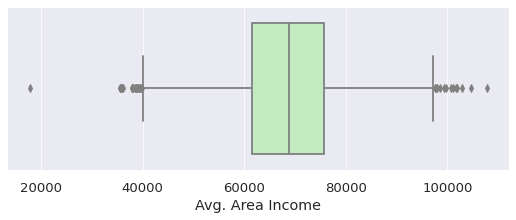

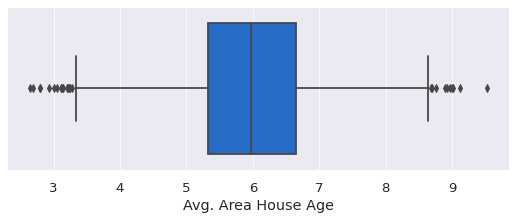

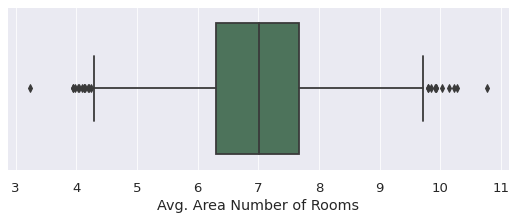

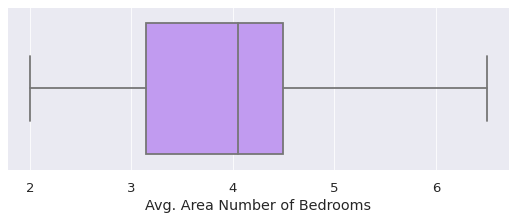

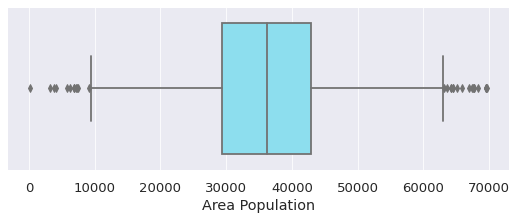

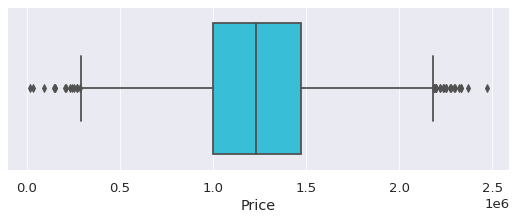

In [17]:
sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 1.8})
for i in df.columns[:-1]:
    fig,ax = plt.subplots(figsize = (9,3))
    color = np.random.rand(3,)
    ax = sns.boxplot(x=df[i],color = random_color())

### Bivariate Data Analysis

#### Regressionrplot,Bivariate KDE,Hexbin and correlation coefficients

In [18]:
def bivariate_plot(column,color):
    sns.set_context("paper", font_scale=1.8, rc={"lines.linewidth": 1.8})
    sns.set_style('white')
    import scipy.stats
    fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize = (21,6))
    sns.regplot(data = df,x=column, y='Price',ax = ax1,color = color,line_kws ={'color' :'red'})
    sns.kdeplot(data=df,x=column,y="Price",ax =ax2,color = color,)
    df.plot.hexbin(x=column, y='Price', gridsize=9,ax = ax3,cmap=plt.cm.Blues)
    fig.suptitle(column, fontsize=18)
    sns.despine()
    plt.show()
    print('Pearson\' correlation coefficient :',df[column].corr(df['Price']))
    print('Spearman\'s correlation coefficient :',df[column].corr(df['Price'],method = 'spearman'))
    print('Kendall\'s correlation coefficient :',df[column].corr(df['Price'],method = 'kendall'))

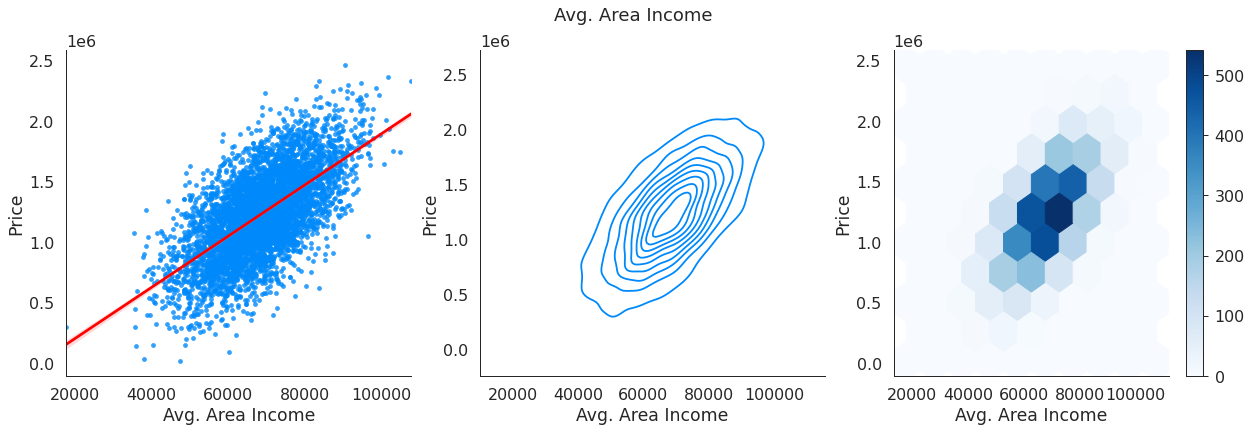

Pearson' correlation coefficient : 0.6397337782498939
Spearman's correlation coefficient : 0.6199618621744744
Kendall's correlation coefficient : 0.4407702340468094


In [19]:
bivariate_plot('Avg. Area Income','#0089fa')

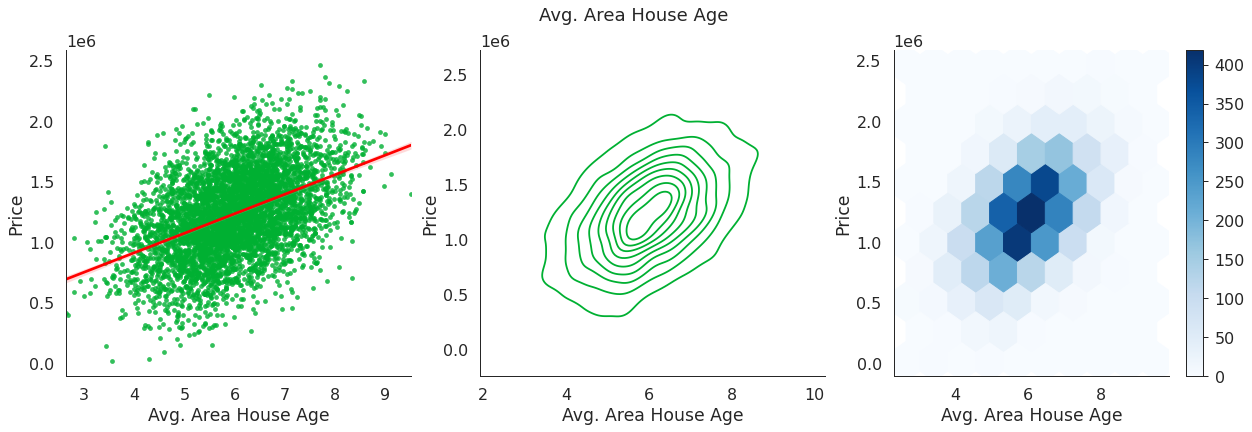

Pearson' correlation coefficient : 0.45254253717875575
Spearman's correlation coefficient : 0.4427245926209837
Kendall's correlation coefficient : 0.30346661332266456


In [20]:
bivariate_plot('Avg. Area House Age','#00b032')

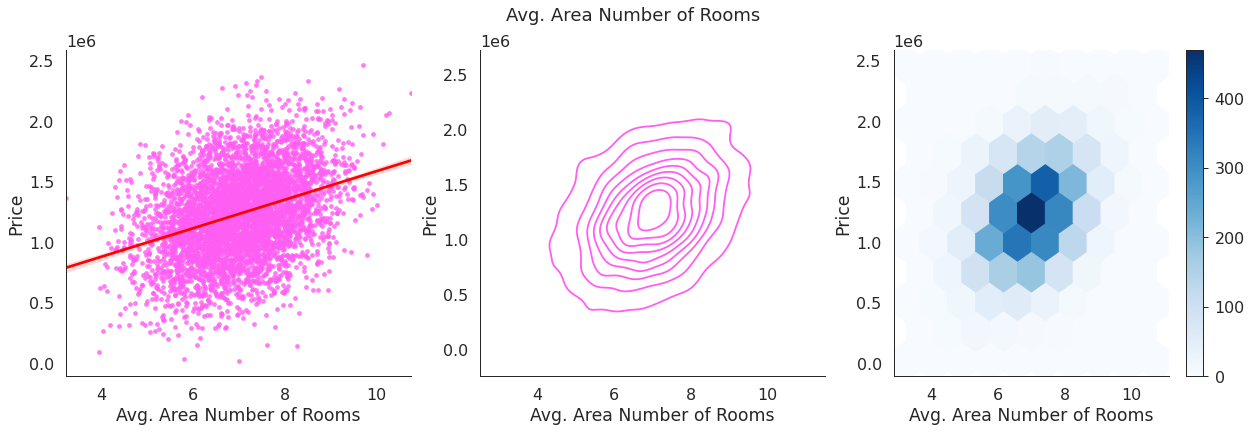

Pearson' correlation coefficient : 0.33566445336675954
Spearman's correlation coefficient : 0.3179236691969467
Kendall's correlation coefficient : 0.21595695139027807


In [21]:
bivariate_plot('Avg. Area Number of Rooms','#ff5ef2')

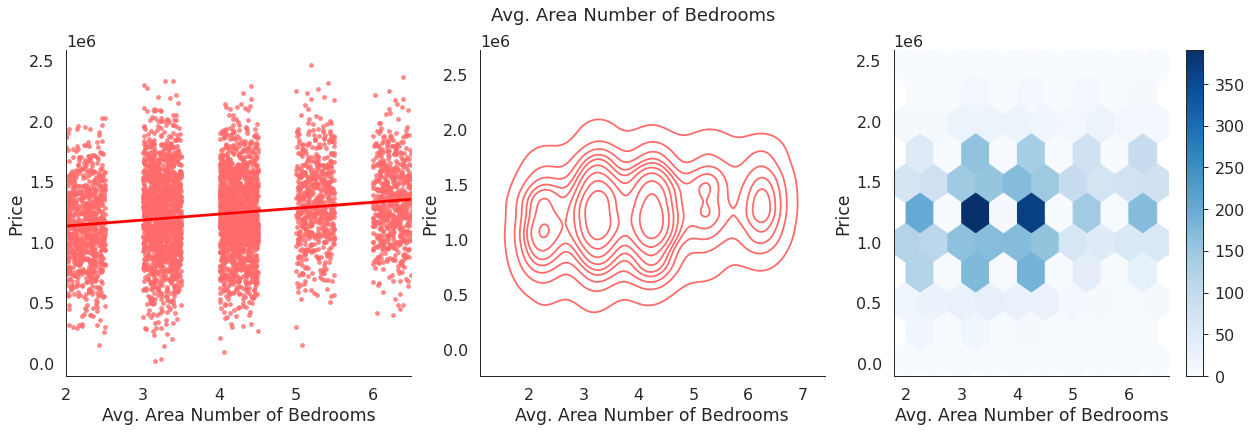

Pearson' correlation coefficient : 0.17107102765855592
Spearman's correlation coefficient : 0.1581727049551064
Kendall's correlation coefficient : 0.10542909856797184


In [22]:
bivariate_plot('Avg. Area Number of Bedrooms','#ff6b6b')

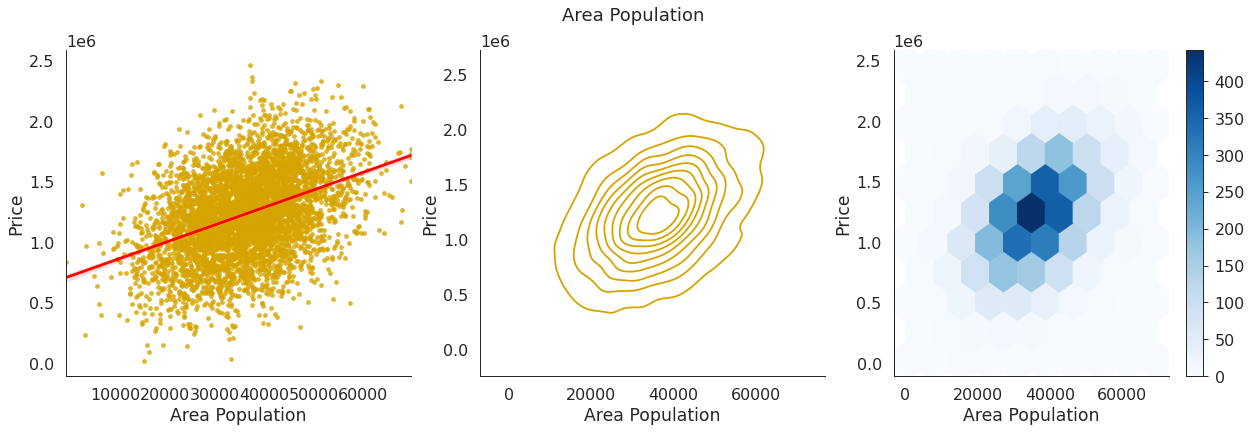

Pearson' correlation coefficient : 0.4085558793165562
Spearman's correlation coefficient : 0.3946491364259654
Kendall's correlation coefficient : 0.2696123224644929


In [23]:
bivariate_plot('Area Population','#d6a400')

### Multivariate  Data Analysis

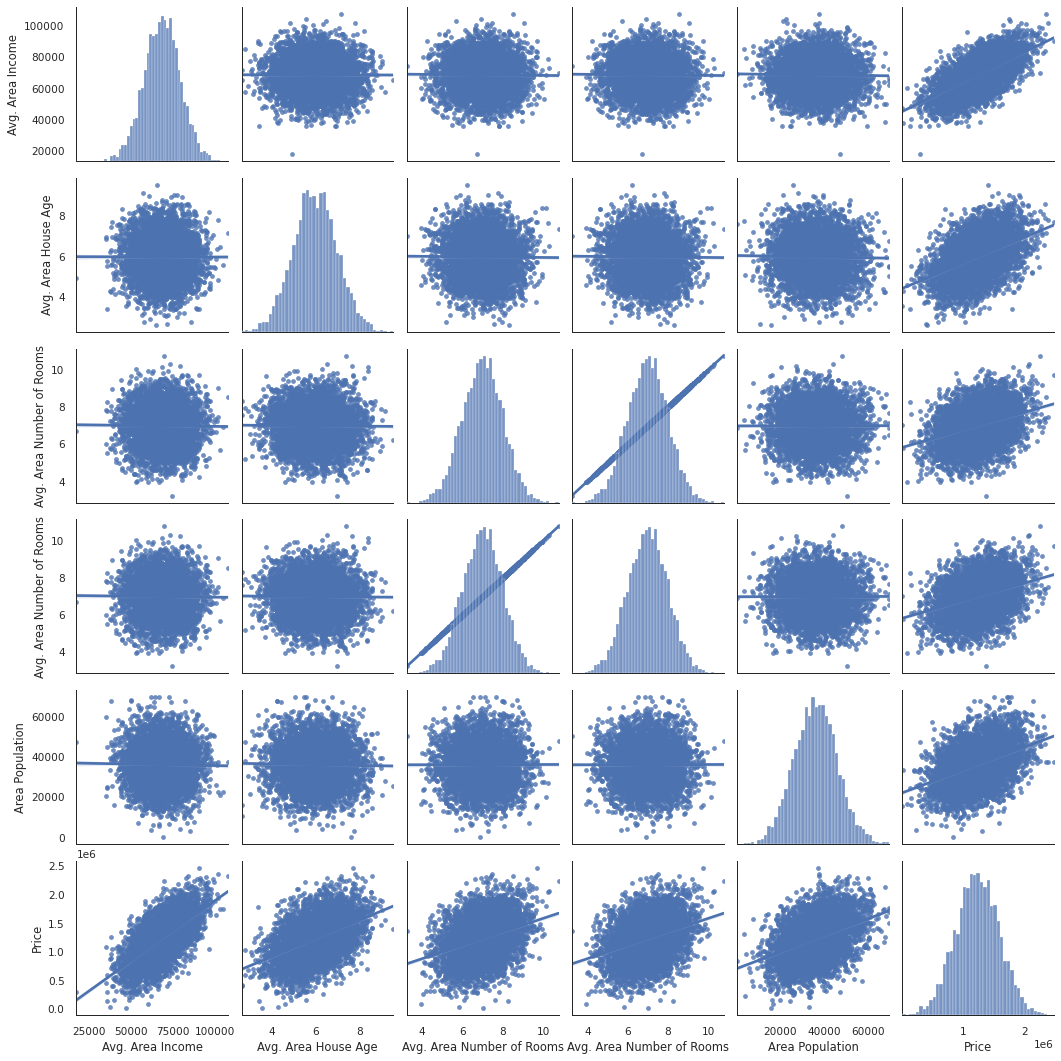

In [24]:
sns.set_context("paper", font_scale=1.2, rc={"lines.linewidth": 1.8})
sns.pairplot(df,vars = ['Avg. Area Income',
                        'Avg. Area House Age','Avg. Area Number of Rooms',
                        'Avg. Area Number of Rooms','Area Population','Price'],kind= 'reg')

Text(0.5, 1.0, 'Address Vs Price')

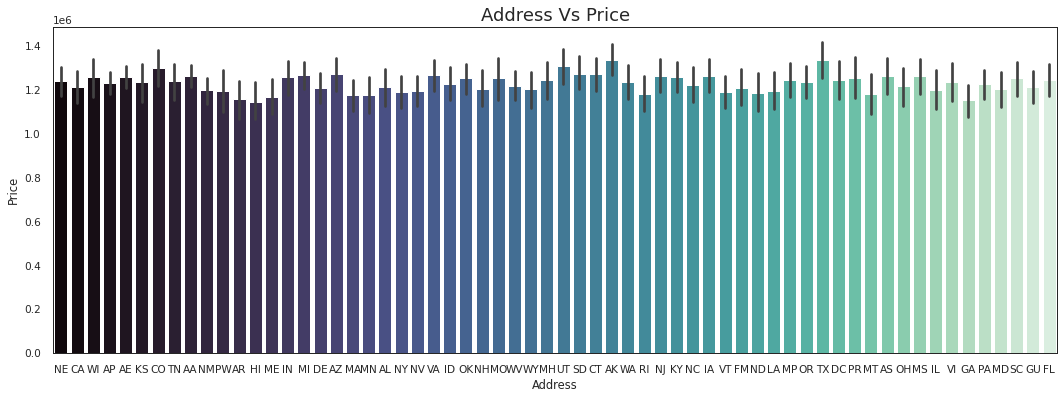

In [25]:
fig,ax = plt.subplots(figsize = (18,6))
sns.set_theme(style="darkgrid")
ax = sns.barplot(x="Address", y="Price", data=df,palette = 'mako')
ax.set_title('Address Vs Price',size = 18)

Text(0.5, 1.0, 'Address Vs Area Population')

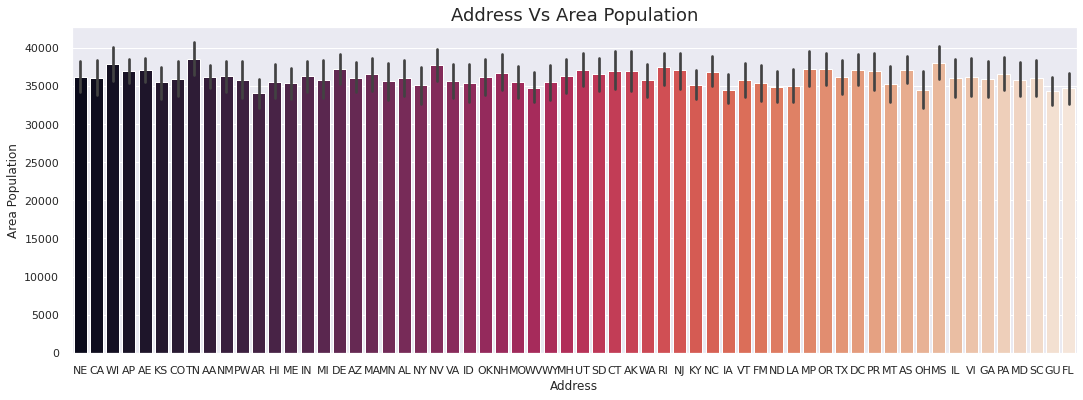

In [26]:
fig,ax = plt.subplots(figsize = (18,6))
sns.set_theme(style="darkgrid")
ax = sns.barplot(x="Address", y="Area Population", data=df,palette = 'rocket')
ax.set_title('Address Vs Area Population',size = 18)

In [27]:
#correlation matrix
corr = df.corr(method = 'pearson')
corr

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


<AxesSubplot:>

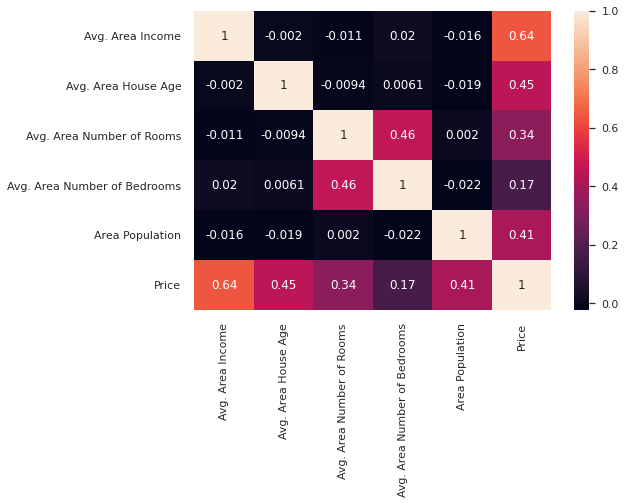

In [28]:
sns.heatmap(corr,xticklabels = corr.columns,yticklabels = corr.columns,annot=True)

#### Removing with Outliers

In [29]:
def remove_outliers(df):
    outliers = {}
    for col in df.columns:
        if str(df[col].dtype) != 'object':
            df = df[np.abs(df[col]-df[col].mean()) < (3*df[col].std())]
            olrs = df[~(np.abs(df[col]-df[col].mean()) < (3*df[col].std()))]
            outliers = pd.DataFrame(olrs)        
    return df            
df_outlier = remove_outliers(df)

### Variable Transforamtion (if necessary)

#### Check the quantiles

In [30]:
def diagnostic_plots(df, variable):
    
    plt.figure(figsize=(15,6))
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.suptitle(variable, fontsize=16)
    plt.show()

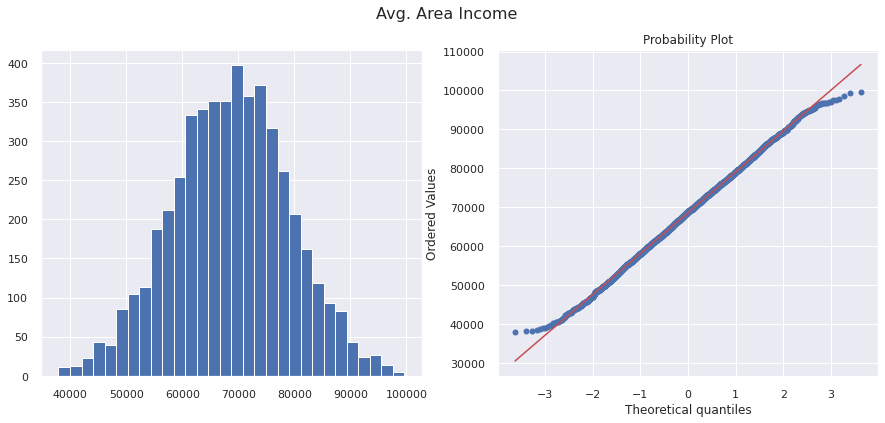

In [31]:
diagnostic_plots(df_outlier, 'Avg. Area Income')

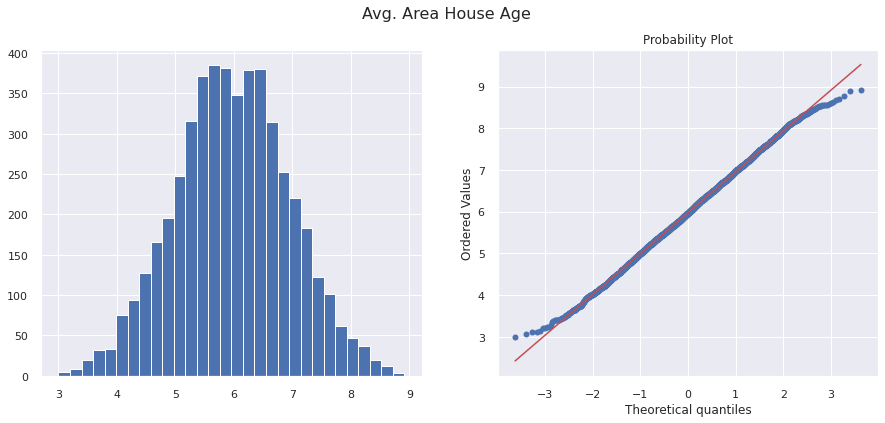

In [32]:
diagnostic_plots(df_outlier, 'Avg. Area House Age')

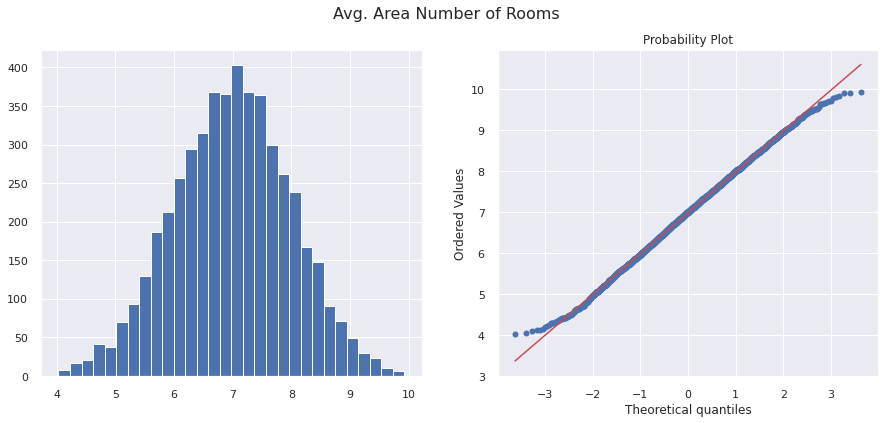

In [33]:
diagnostic_plots(df_outlier, 'Avg. Area Number of Rooms')

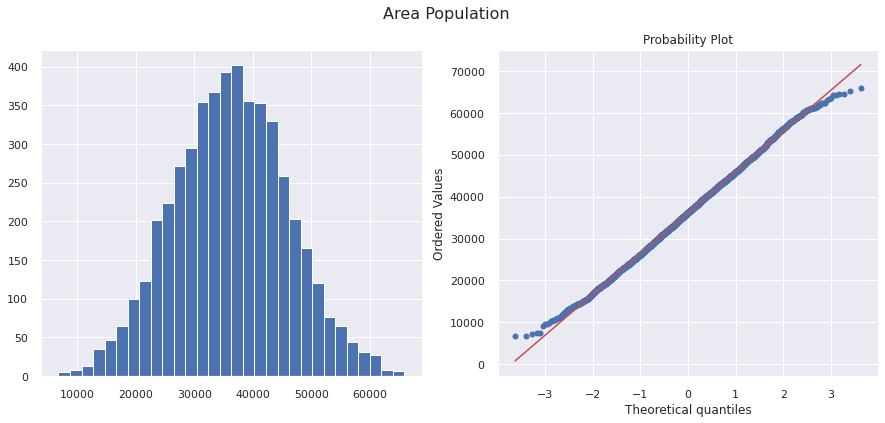

In [34]:
diagnostic_plots(df_outlier, 'Area Population')

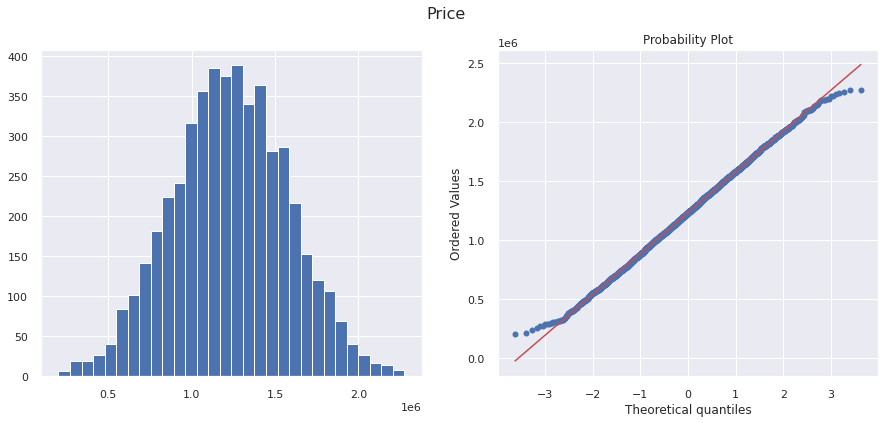

In [35]:
diagnostic_plots(df_outlier, 'Price')

All the Variavble except (Avg. Area Number of Bedrooms) are approximately normally distributed.

### Model Building

In [36]:
y = df_outlier['Price']
#log transform target variable
y = np.log1p(y)

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    df_outlier.drop(['Price','Address'],axis = 1), y, test_size=0.3, random_state=0)

#### Standard Scaling

In [39]:
from sklearn.preprocessing import MinMaxScaler

In [40]:
scaler = MinMaxScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

#### Measuring Performance

In [41]:
from sklearn.model_selection import cross_val_score
#create an empty dictionary to store data.
model_performance = {}

In [42]:
from sklearn import metrics
def print_evaluate(true,predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)

#### Visualizing

In [43]:
def plot(Model,test_pred):
    fig,ax = plt.subplots(figsize = (9,6))
    plt.scatter(y_test, test_pred, c='#0097e3',s = 6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', c='red', lw=2.7)
    plt.xlabel('Actuals')
    plt.ylabel('Predicted Values')
    plt.title('Actuals Vs Predicted Values')
    plt.suptitle(Model,fontsize = 16)
    plt.show()
    # increase size

#### Linear Regression

In [44]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression(normalize=True)
lin_reg.fit(X_train_std,y_train)

LinearRegression(normalize=True)

In [45]:
test_pred = lin_reg.predict(X_test_std)
train_pred = lin_reg.predict(X_train_std)

In [46]:
print("------TEST------")
print()
print_evaluate(y_test,test_pred)
print()
print("------TRAIN------")
print_evaluate(y_train,train_pred)

------TEST------

MAE: 0.08414450410548423
MSE: 0.012438097923088368
RMSE: 0.11152622078725867
R2 Square 0.8699655664189854

------TRAIN------
MAE: 0.0867323287701274
MSE: 0.014241176593181913
RMSE: 0.1193364009562125
R2 Square 0.8607199250579072


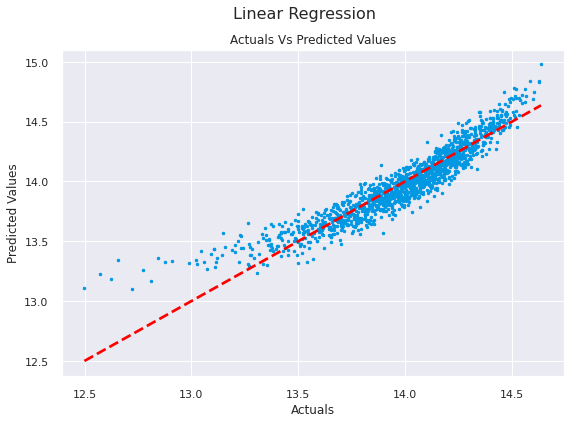

In [47]:
plot('Linear Regression',test_pred)

In [48]:
#get the cross val score
score = cross_val_score(lin_reg, X_train_std, y_train, cv=9,).mean()

In [49]:
model_performance['Linear Regression(Simple)'] = score

#### Lasso Regression (L1 Regularization)

In [50]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
parameters = {"alpha": [0.01,0.09,0.1,1,2,5,10,100],"normalize":[True,False] ,"positive" : [True,False],
              'fit_intercept' : [True,False]}

In [51]:
gridsearch = GridSearchCV(Lasso(), parameters)
gridsearch.fit(X_train_std, y_train)

GridSearchCV(estimator=Lasso(),
             param_grid={'alpha': [0.01, 0.09, 0.1, 1, 2, 5, 10, 100],
                         'fit_intercept': [True, False],
                         'normalize': [True, False],
                         'positive': [True, False]})

In [52]:
gridsearch.best_params_

{'alpha': 0.01, 'fit_intercept': True, 'normalize': False, 'positive': True}

In [53]:
#building the best Lasso Regression Model
lasso_reg = Lasso(alpha = 0.01,fit_intercept = True,normalize = False, positive = True)
lasso_reg.fit(X_train_std,y_train)

Lasso(alpha=0.01, positive=True)

In [54]:
test_pred = lasso_reg.predict(X_test_std)
train_pred = lasso_reg.predict(X_train_std)

In [55]:
print("------TEST------")
print()
print_evaluate(y_test,test_pred)
print()
print("------TRAIN------")
print_evaluate(y_train,train_pred)

------TEST------

MAE: 0.11613656192572244
MSE: 0.02510945404022985
RMSE: 0.1584596290549421
R2 Square 0.7374925286937211

------TRAIN------
MAE: 0.12109270169778155
MSE: 0.029241947156892108
RMSE: 0.17100276944217047
R2 Square 0.714010948125273


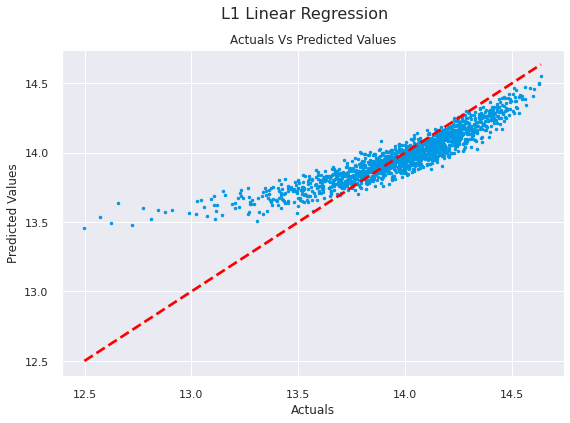

In [56]:
plot('L1 Linear Regression',test_pred)

In [57]:
#get the cross val score
score = cross_val_score(lasso_reg, X_train_std, y_train, cv=9,).mean()
model_performance['Linear Regression(Lasso)'] = score

#### Ridge Regression (L2 Regularization)

In [58]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
parameters = {"alpha": [0.01,0.09,0.1,1,2,5,10,100],"normalize":[True,False] ,
              'fit_intercept' : [True,False]}

In [59]:
gridsearch = GridSearchCV(Ridge(), parameters)
gridsearch.fit(X_train_std, y_train)

GridSearchCV(estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.09, 0.1, 1, 2, 5, 10, 100],
                         'fit_intercept': [True, False],
                         'normalize': [True, False]})

In [60]:
gridsearch.best_params_

{'alpha': 0.1, 'fit_intercept': True, 'normalize': False}

In [61]:
#Building the best Ridge mdoel
ridge_reg = Ridge(alpha = 0.1,fit_intercept = True,normalize = False)
ridge_reg.fit(X_train_std,y_train)

Ridge(alpha=0.1)

In [62]:
test_pred = ridge_reg.predict(X_test_std)
train_pred = ridge_reg.predict(X_train_std)

In [63]:
print("------TEST------")
print()
print_evaluate(y_test,test_pred)
print()
print("------TRAIN------")
print_evaluate(y_train,train_pred)

------TEST------

MAE: 0.08408837082807934
MSE: 0.012431141339002645
RMSE: 0.11149502831517935
R2 Square 0.8700382942168239

------TRAIN------
MAE: 0.0866934474387303
MSE: 0.014241281029915205
RMSE: 0.11933683852823991
R2 Square 0.8607189036566245


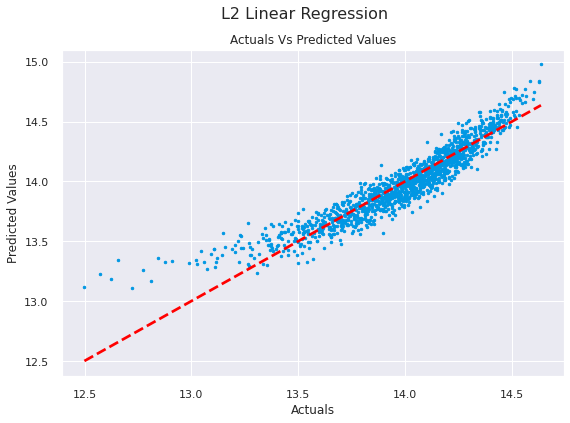

In [64]:
plot('L2 Linear Regression',test_pred)

In [65]:
#get the cross val score
score = cross_val_score(ridge_reg, X_train_std, y_train, cv=9,).mean()
model_performance['Linear Regression(Ridge)'] = score

#### PloynomialRegrression

#### Chosing the best degree polynomial


In [66]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score 
degrees = [2, 3, 4, 5, 6] # Change degree "hyperparameter" here
normalizes = [True, False] # Change normalize hyperparameter here
best_score = 0
best_degree = 0
poly_reg = {
    'degree' : [],
    'normalize' : [],
    'scores' : [],
    'r2_score' : [],
}
for degree in degrees:
    for normalize in normalizes:
        poly_features = PolynomialFeatures(degree = degree)
        scaler = MinMaxScaler()
        
        X_train_poly = scaler.fit_transform(poly_features.fit_transform(X_train))
        X_test_poly = scaler.transform(poly_features.transform(X_test))
        
        polynomial_regressor = LinearRegression(normalize=normalize)
        polynomial_regressor.fit(X_train_poly, y_train)
        scores = cross_val_score(polynomial_regressor, X_train_poly, y_train, cv=6)
        test_pred = polynomial_regressor.predict(X_test_poly)
        
        r2_score = metrics.r2_score(y_test, test_pred)
        
        # Change k-fold cv value here
        poly_reg['degree'].append(degree)
        poly_reg['normalize'].append(normalize)
        poly_reg['scores'].append(scores.mean())
        poly_reg['r2_score'].append(r2_score)
    

In [67]:
pd.DataFrame(poly_reg)

,degree,normalize,scores,r2_score
0,2,True,0.897579,0.904587
1,2,False,0.897579,0.904587
2,3,True,0.899025,0.905213
3,3,False,0.899025,0.905213
4,4,True,0.896496,0.899021
5,4,False,0.896496,0.899021
6,5,True,0.888190,0.888811
7,5,False,0.888190,0.888811
8,6,True,0.847297,0.862679
9,6,False,0.847297,0.862679


The best polynomial degree is 3

In [68]:
poly_reg = PolynomialFeatures(degree = 3)
from sklearn.preprocessing import PolynomialFeatures
scaler = MinMaxScaler()

#polynomial scale
poly_reg = PolynomialFeatures(degree = 3)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

#standaer scale
X_train_std_ploy = scaler.fit_transform(X_train_poly)
X_test_std_ploy = scaler.transform(X_test_poly)

ploy_reg = LinearRegression()
ploy_reg.fit(X_train_std_ploy, y_train)

LinearRegression()

In [69]:
test_pred = ploy_reg.predict(X_test_std_ploy)
train_pred = ploy_reg.predict(X_train_std_ploy)

In [70]:
print("------TEST------")
print()
print_evaluate(y_test,test_pred)
print()
print("------TRAIN------")
print_evaluate(y_train,train_pred)

------TEST------

MAE: 0.07213459726725839
MSE: 0.00906659277632896
RMSE: 0.09521865771123304
R2 Square 0.905213058823795

------TRAIN------
MAE: 0.07405840460973576
MSE: 0.009910772047402447
RMSE: 0.09955286056865692
R2 Square 0.9030716974496983


The best model is of Polynomial degree 3.

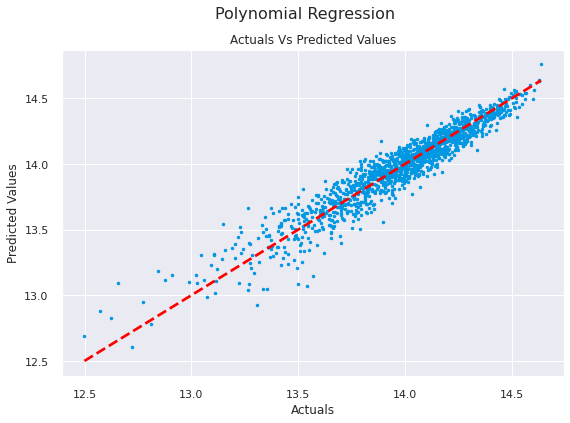

In [71]:
plot('Polynomial Regression',test_pred)

In [72]:
#get the cross val score
score = cross_val_score(ploy_reg, X_train_std_ploy, y_train, cv=9,).mean()
model_performance['Polynomial Regression'] = score

#### KNN Regression

In [73]:
scaler = MinMaxScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
from sklearn.neighbors import KNeighborsRegressor

In [74]:
neigh = KNeighborsRegressor(n_neighbors=3)
neigh.fit(X_train_std, y_train)

KNeighborsRegressor(n_neighbors=3)

In [75]:
test_pred = neigh.predict(X_test_std)
train_pred = neigh.predict(X_train_std)

In [76]:
print("------TEST------")
print()
print_evaluate(y_test,test_pred)
print()
print("------TRAIN------")
print_evaluate(y_train,train_pred)

------TEST------

MAE: 0.09403523026409401
MSE: 0.015125005823042345
RMSE: 0.12298376243651983
R2 Square 0.8418752145809999

------TRAIN------
MAE: 0.0721808655268038
MSE: 0.009463447414649979
RMSE: 0.09728025192530075
R2 Square 0.9074465753234153


##### Hyperparameter Tuning

In [77]:
parameters = {
    'n_neighbors' :np.arange(1,50),
    "weights" : ['uniform','distance'],
    "p" : [1,2],    
}

In [78]:
gridsearch = GridSearchCV(KNeighborsRegressor(), parameters)
gridsearch.fit(X_train_std, y_train)

GridSearchCV(estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'p': [1, 2], 'weights': ['uniform', 'distance']})

In [79]:
gridsearch.best_params_

{'n_neighbors': 11, 'p': 2, 'weights': 'distance'}

In [80]:
#buliding the best KNNRegressor model
neigh = KNeighborsRegressor(n_neighbors=11,p = 2,weights = 'distance')
neigh.fit(X_train_std, y_train)

KNeighborsRegressor(n_neighbors=11, weights='distance')

In [81]:
test_pred = neigh.predict(X_test_std)
train_pred = neigh.predict(X_train_std)

In [82]:
print("------TEST------")
print()
print_evaluate(y_test,test_pred)
print()
print("------TRAIN------")
print_evaluate(y_train,train_pred)

------TEST------

MAE: 0.0859766121403876
MSE: 0.013057651149777003
RMSE: 0.11427007985372638
R2 Square 0.86348843033243

------TRAIN------
MAE: 0.0
MSE: 0.0
RMSE: 0.0
R2 Square 1.0


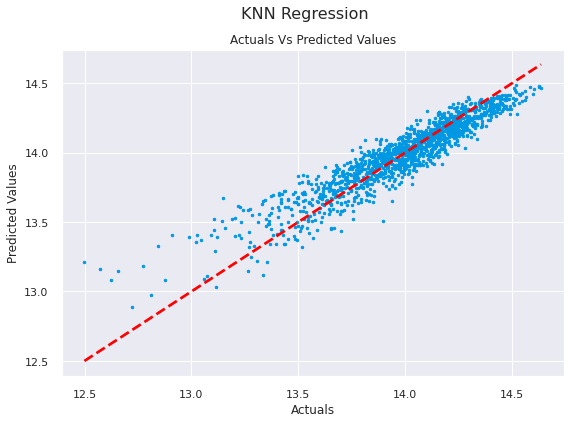

In [83]:
plot('KNN Regression',test_pred)

In [84]:
#get the cross val score
score = cross_val_score(neigh, X_train_std, y_train, cv=9,).mean()
model_performance['KNN Regression'] = score

#### Support Vector Regressor (SVR)

In [85]:
from sklearn.svm import SVR

In [86]:
regr = SVR(kernel = 'linear')

In [87]:
regr.fit(X_train_std, y_train)

SVR(kernel='linear')

In [88]:
test_pred = regr.predict(X_test_std)
train_pred = regr.predict(X_train_std)

In [89]:
print("------TEST------")
print()
print_evaluate(y_test,test_pred)
print()
print("------TRAIN------")
print_evaluate(y_train,train_pred)

------TEST------

MAE: 0.08229890994107025
MSE: 0.012341559519808098
RMSE: 0.11109257184802275
R2 Square 0.8709748297860203

------TRAIN------
MAE: 0.0853118249437362
MSE: 0.014395151279004325
RMSE: 0.11997979529489257
R2 Square 0.8592140378413412


##### Hyperparameter Tuning

In [90]:
parameters = {
    'kernel' :['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma' : ['scale','auto'],

}

In [91]:
gridsearch = GridSearchCV(SVR(), parameters)
gridsearch.fit(X_train_std, y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']})

In [92]:
gridsearch.best_params_

{'gamma': 'scale', 'kernel': 'rbf'}

In [93]:
#building the best SVR() mdoel
regr = SVR(kernel = 'rbf',gamma = 'scale')
regr.fit(X_train_std, y_train)

SVR()

In [94]:
test_pred = regr.predict(X_test_std)
train_pred = regr.predict(X_train_std)

In [95]:
print("------TEST------")
print()
print_evaluate(y_test,test_pred)
print()
print("------TRAIN------")
print_evaluate(y_train,train_pred)

------TEST------

MAE: 0.07555177685169473
MSE: 0.00980114253894417
RMSE: 0.09900071989104003
R2 Square 0.8975336883196093

------TRAIN------
MAE: 0.07373680989005052
MSE: 0.0095434452472831
RMSE: 0.09769055863942584
R2 Square 0.9066641888364954


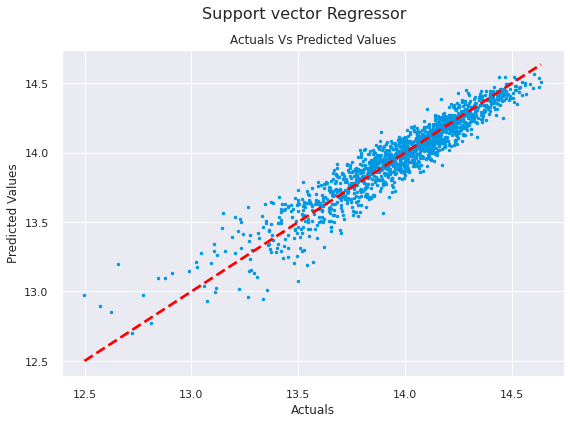

In [96]:
plot('Support vector Regressor',test_pred)

In [97]:
#get the cross val score
score = cross_val_score(regr, X_train_std, y_train, cv=9,).mean()
model_performance['SVR(kernel = rbf)'] = score

#### Visualizing the model performance

In [98]:
model_df = pd.DataFrame.from_dict(model_performance,orient = 'index',columns = ['Mean CV Score'])
model_df = model_df.sort_values(by ='Mean CV Score',ascending = False)
model_df

,Mean CV Score
Polynomial Regression,0.898498
SVR(kernel = rbf),0.888431
Linear Regression(Ridge),0.860176
Linear Regression(Simple),0.860173
KNN Regression,0.842371
Linear Regression(Lasso),0.713586


<AxesSubplot:xlabel='Mean CV Score'>

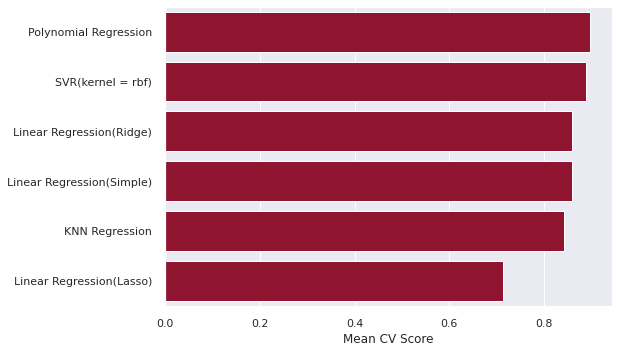

In [99]:
sns.barplot(x="Mean CV Score", y=model_df.index, data=model_df,color = '#a30023')